In [5]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Variables simbólicas
r_L, r_C, r_R, r_I = sp.symbols('r_L r_C r_R r_I')
R, RI = sp.symbols('R RI')
I0 = sp.Symbol('I0')
s0, c, g = sp.symbols('s0 c g')
tau, tau_I = sp.symbols('tau tau_I')
x = sp.Symbol('x')

# Definir phi como función a trozos
phi_piecewise = sp.Piecewise(
    (0, x < 0),
    (x**2, (x >= 0) & (x <= 1)),
    (2 * sp.sqrt(x - sp.Rational(3, 4)), x > 1)
)

# Derivada simbólica de phi(x)
phi_prime = sp.diff(phi_piecewise, x)

# Argumentos para phi
phi_arg = s0 * R - c * RI + I0
phiI_arg = g / 3 * (3 * R) + I0  # r_L + r_C + r_R = 3R

# Evaluamos las derivadas en esos puntos
dphi_val_expr = phi_prime.subs(x, phi_arg)
dphiI_val_expr = phi_prime.subs(x, phiI_arg)

# Sistema
f1 = (1/tau)*(-r_L + phi_piecewise.subs(x, s0*r_L - c*r_I + I0))
f2 = (1/tau)*(-r_C + phi_piecewise.subs(x, s0*r_C - c*r_I + I0))
f3 = (1/tau)*(-r_R + phi_piecewise.subs(x, s0*r_R - c*r_I + I0))
f4 = (1/tau_I)*(-r_I + phi_piecewise.subs(x, g/3*(r_L + r_C + r_R) + I0))

vars = sp.Matrix([r_L, r_C, r_R, r_I])
F = sp.Matrix([f1, f2, f3, f4])
J = F.jacobian(vars)

# Sustitución del punto fijo
subs_fixed_point = {
    r_L: R,
    r_C: R,
    r_R: R,
    r_I: RI
}

# Jacobiano evaluado
J_eval = J.subs(subs_fixed_point)

# Sustituimos parámetros constantes
params = {
    s0: 1.0,
    c: 1.0,
    g: 1.0,
    tau: 1.0,
    tau_I: 1.0,
    R: 1/4,
    RI: 1/4
}

# Vector para resultados
I0_vals = np.linspace(-1, 1, 300)
eigvals_list = []

for i0_val in I0_vals:
    # Sustituimos I0
    full_subs = {I0: i0_val, **params}
    # Evaluamos derivadas de phi
    dphi_val = float(dphi_val_expr.evalf(subs=full_subs))
    dphiI_val = float(dphiI_val_expr.evalf(subs=full_subs))

    # Sustituimos manualmente derivadas
    J_num = J_eval.subs(full_subs)

    # Sustituciones derivadas
    J_num = J_num.subs([
        (sp.diff(phi_piecewise.subs(x, s0*r_L - c*r_I + I0), r_L), params[s0]*dphi_val),
        (sp.diff(phi_piecewise.subs(x, s0*r_C - c*r_I + I0), r_C), params[s0]*dphi_val),
        (sp.diff(phi_piecewise.subs(x, s0*r_R - c*r_I + I0), r_R), params[s0]*dphi_val),
        (sp.diff(phi_piecewise.subs(x, s0*r_L - c*r_I + I0), r_I), -params[c]*dphi_val),
        (sp.diff(phi_piecewise.subs(x, g/3*(r_L + r_C + r_R) + I0), r_L), (params[g]/3)*dphiI_val),
        (sp.diff(phi_piecewise.subs(x, g/3*(r_L + r_C + r_R) + I0), r_C), (params[g]/3)*dphiI_val),
        (sp.diff(phi_piecewise.subs(x, g/3*(r_L + r_C + r_R) + I0), r_R), (params[g]/3)*dphiI_val),
    ])

    # Convertimos a NumPy
    J_np = np.array(J_num).astype(np.float64)
    eigvals = np.linalg.eigvals(J_np)
    eigvals_list.append(eigvals)

# Convertimos a array
eigvals_array = np.array(eigvals_list)

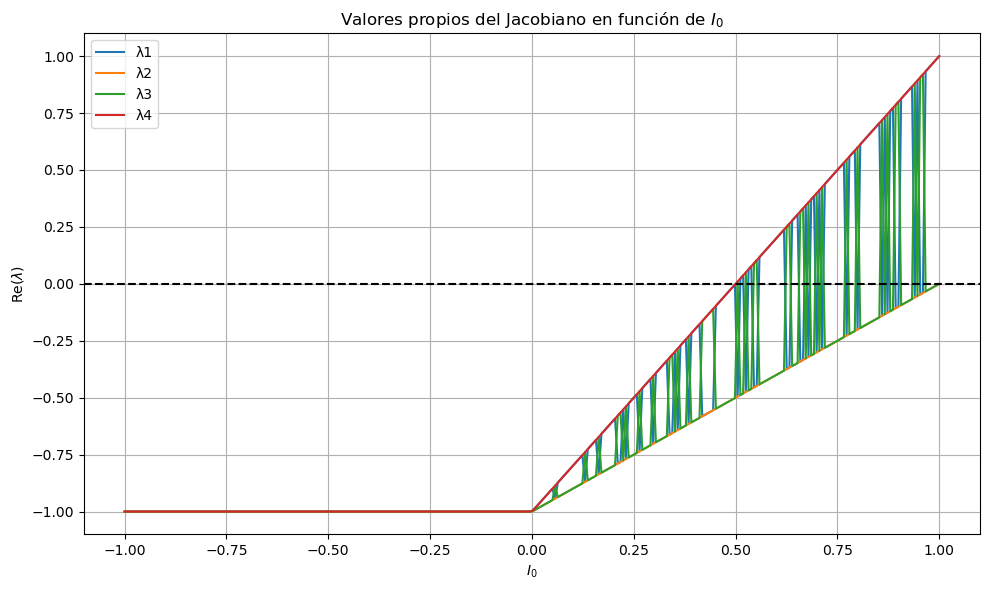

In [6]:
# Plot
plt.figure(figsize=(10, 6))
for i in range(4):
    plt.plot(I0_vals, np.real(eigvals_array[:, i]), label=f'λ{i+1}')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('$I_0$')
plt.ylabel('Re($\\lambda$)')
plt.title('Valores propios del Jacobiano en función de $I_0$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


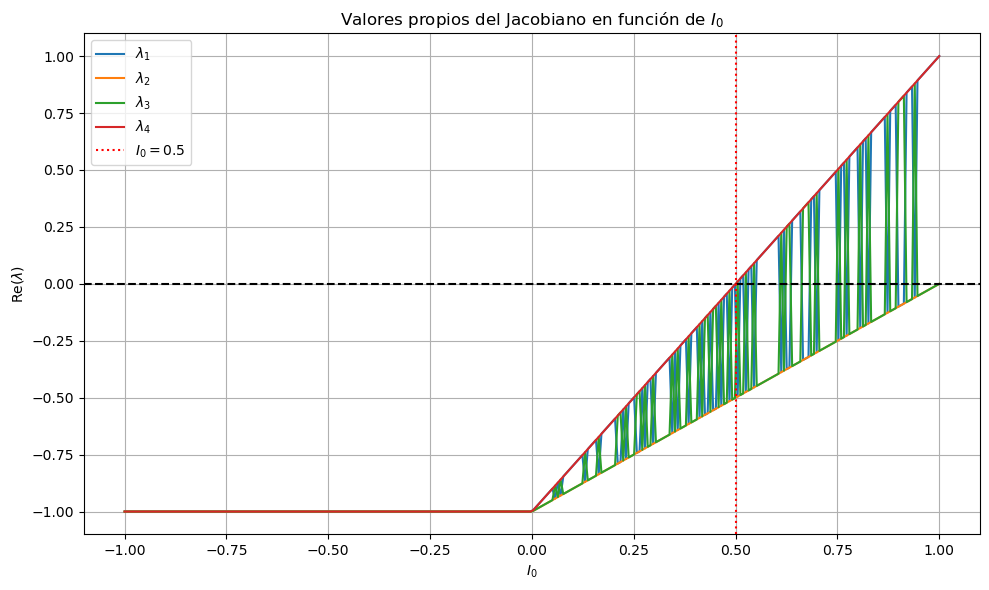

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Derivada de phi como función de numpy
def dphi(x):
    if x < 0:
        return 0.0
    elif 0 <= x <= 1:
        return 2 * x
    else:
        return 1 / np.sqrt(x - 0.75)

# Derivada vectorizada
dphi_vec = np.vectorize(dphi)

# Parámetros
s0 = 1.0
c = 1.0
g = 1.0
tau = 1.0
tau_I = 1.0
R = 1.0
RI = 1.0

# Variables independientes
I0_vals = np.linspace(-1, 1, 300)
eigvals_list = []

for I0 in I0_vals:
    # Argumentos donde se evalúa phi'
    x_phi = s0 * R - c * RI + I0
    x_phiI = g * R + I0

    dphi_val = dphi(x_phi)
    dphiI_val = dphi(x_phiI)

    # Jacobiano numérico
    J = np.array([
        [(-1 + s0 * dphi_val) / tau, 0, 0, (-c * dphi_val) / tau],
        [0, (-1 + s0 * dphi_val) / tau, 0, (-c * dphi_val) / tau],
        [0, 0, (-1 + s0 * dphi_val) / tau, (-c * dphi_val) / tau],
        [(g / 3) * dphiI_val / tau_I, (g / 3) * dphiI_val / tau_I, (g / 3) * dphiI_val / tau_I, -1 / tau_I]
    ])
    vals = np.linalg.eigvals(J)
    eigvals_list.append(vals)

eigvals_array = np.array(eigvals_list)

# Graficar
plt.figure(figsize=(10, 6))
for i in range(4):
    plt.plot(I0_vals, np.real(eigvals_array[:, i]), label=f'$\\lambda_{i+1}$')
plt.axhline(0, color='black', linestyle='--')
plt.axvline(0.5, color='red', linestyle=':', label='$I_0=0.5$')
plt.xlabel('$I_0$')
plt.ylabel('Re($\\lambda$)')
plt.title('Valores propios del Jacobiano en función de $I_0$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


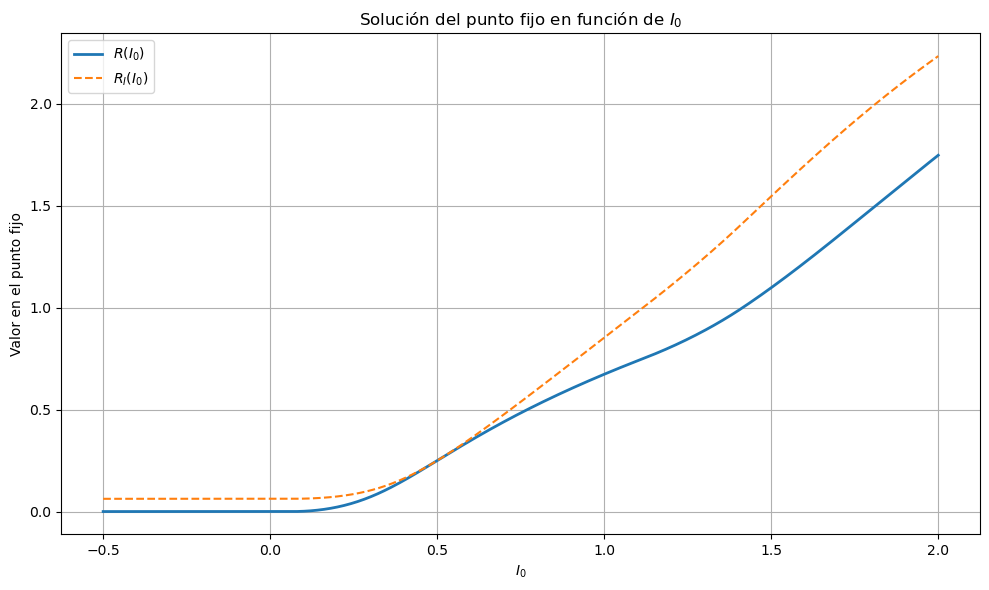

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Definimos phi
def phi(x):
    if x < 0:
        return 0
    elif 0 <= x <= 1:
        return x**2
    else:
        return 2 * np.sqrt(x - 0.75)

# Vectorizar para arrays
phi_vec = np.vectorize(phi)

# Parámetros
s0 = 1.0
c = 1.0
g = 1.0

I_I = 1/4
# Sistema a resolver: devuelve [R - phi(...), RI - phi(...)]
def fixed_point_eq(vars, I0):
    R, RI = vars
    eq1 = R - phi(s0 * R - c * RI + I0)
    eq2 = RI - phi(g * R + I_I)
    return [eq1, eq2]

# Valores de I0
I0_vals = np.linspace(-0.5, 2, 500)
R_vals = []
RI_vals = []

# Valor inicial para fsolve
init = [0.5, 0.5]

for I0 in I0_vals:
    try:
        sol = fsolve(fixed_point_eq, init, args=(I0,))
        R_vals.append(sol[0])
        RI_vals.append(sol[1])
        init = sol  # usar como punto de partida para siguiente
    except:
        R_vals.append(np.nan)
        RI_vals.append(np.nan)

# Convertir a array
R_vals = np.array(R_vals)
RI_vals = np.array(RI_vals)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(I0_vals, R_vals, label='$R(I_0)$', linewidth=2)
plt.plot(I0_vals, RI_vals, label='$R_I(I_0)$', linestyle='--')
plt.xlabel('$I_0$')
plt.ylabel('Valor en el punto fijo')
plt.title('Solución del punto fijo en función de $I_0$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
